# KPIs

## Librerías

In [45]:
import pandas as pd

## Documentos

In [46]:
from pathlib import Path

# -------------------------------------------
# RUTAS DE LOS DATASETS LIMPIOS POR SEMANA
# Cada fecha corresponde al lunes de medición
# -------------------------------------------

archivos_semanales = {
    '2026-05-25': '../../Data/clean/clean_data_25052026.csv',
    '2026-06-01': '../../Data/clean/clean_data_01062026.csv',
    '2026-06-08': '../../Data/clean/clean_data_08062026.csv',
    '2026-06-15': '../../Data/clean/clean_data_15062026.csv'
}

# Elegimos qué semana queremos usar para los cálculos 1, 2, 3 y 4 del notebook
fecha_actual = '2026-06-01'
DATA_INPUT_FILE = archivos_semanales[fecha_actual]


In [47]:
# Cargamos el dataset de la semana seleccionada
df = pd.read_csv(DATA_INPUT_FILE)

print(f"Dataset cargado: {fecha_actual}")



Dataset cargado: 2026-06-01


_____________________

## 1. Porcentaje de empleados ausentes (%)
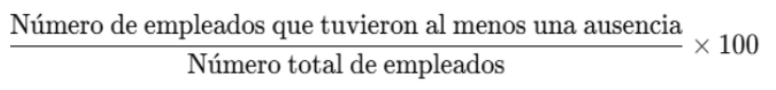

La fórmula busca identificar qué proporción de la plantilla total ha faltado al menos una vez.
* **Variable en el dataset:** `ID` (para identificar empleados únicos) y `Absenteeism_hours`.

In [48]:
#Número de empleados con al menos una ausencia (horas > 0)
empleados_ausentes = df[df['Absenteeism_hours'] > 0]['ID'].nunique()

#Número total de empleados únicos
total_empleados = df['ID'].nunique()

porcentaje_ausentes = round((empleados_ausentes / total_empleados) * 100, 2)

In [49]:
print(f"Al menos el {porcentaje_ausentes}% de empleados han tenido al menos una ausencia")

Al menos el 97.79% de empleados han tenido al menos una ausencia


_____________________________

## 2. Mes pico de carga por ausencias
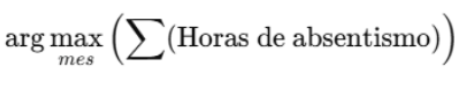

Esta métrica utiliza la función `arg max` para encontrar el mes donde la suma de horas de absentismo es mayor.
*   **Variable en el dataset:** `Month_absence` y `Absenteeism_hours`.

In [50]:
#Agrupamos por mes y sumamos las horas, luego buscamos el índice (mes) con el valor máximo
mes_pico = df.groupby('Month_absence')['Absenteeism_hours'].sum().idxmax()

In [51]:
print(mes_pico)

1.0


El mes pico és Marzo

## 3. Motivo modal de absentismo laboral
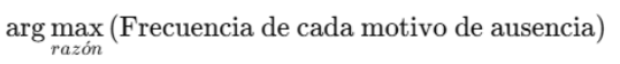

Identifica el motivo (o código ICD) que ocurre con mayor frecuencia en los registros.
*   **Variable en el dataset:** `Reason_absence`.

In [52]:
#Calculamos la moda (frecuencia maxima) de la columna de motivos
frecuencias = df['Reason_absence'].value_counts()

moda = frecuencias.idxmax()
total = frecuencias.max()

print(f"El motivo mas frecuente es: {moda}, con un recuento total de: {total} registros")

El motivo mas frecuente es: 23.0, con un recuento total de: 174 registros


El motivo 23 és: "Consulta medica"

________________
## 4. Índice de eficiencia relativa por carga laboral
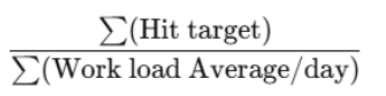

Relaciona el cumplimiento de objetivos (`Hit target`) con la carga de trabajo diaria promedio.
*  **Variable en el dataset:** `Hit_target` y `Work_load_Average_day`.

In [53]:
df['Work_load_Average_day'] = (df['Work_load_Average_day'].astype(str).str.replace(',', '.').astype(float))

#Aplicamos la fórmula: Suma de Hit target / Suma de Work load
indice_eficiencia = round(df['Hit_target'].sum() / df['Work_load_Average_day'].sum(), 2)
print(indice_eficiencia)

0.35


El valor de 0.35 nos sirve como línea de base. Todo grupo o ID que esté por encima de ese valor está rindiendo sobre la media de la empresa, y los que están por debajo podrían ser el foco de nuevas políticas de bienestar o desarrollo profesional

### Consideraciones
Estos KPIs sirven de base para cruzar los datos sociodemográficos (como `Age`, `Education`, `Son` o `Body mass index`) con desempeño operativo. Por ejemplo, se puede analizar si el **Índice de eficiencia relativa** varía significativamente según el nivel de educación o la carga familiar (`Son`) para diseñar las políticas de talento.

## 5. Comparación semanal de KPIs

Esta parte usa los mismos criterios de cálculo de los KPIs anteriores, pero los aplica a cada dataset semanal disponible.

Si todavía no existe el archivo limpio de una semana, el código lo salta y muestra un aviso.


In [54]:
# -------------------------------------------
# COMPARACIÓN SEMANAL DE KPIs
# -------------------------------------------

resultados_kpis = []

for fecha, ruta in archivos_semanales.items():

    if not Path(ruta).exists():
        print(f"No se encontró el archivo de la semana {fecha}: {ruta}")
        continue

    df_semana = pd.read_csv(ruta)

    # KPI 1: Porcentaje de empleados con al menos una ausencia real
    empleados_ausentes = df_semana[df_semana['Absenteeism_hours'] > 0]['ID'].nunique()
    total_empleados = df_semana['ID'].nunique()
    porcentaje_ausentes = round((empleados_ausentes / total_empleados) * 100, 2)

    # KPI 2: Mes pico de carga por ausencias
    mes_pico = df_semana.groupby('Month_absence')['Absenteeism_hours'].sum().idxmax()

    # KPI 3: Motivo modal de absentismo laboral
    frecuencias = df_semana['Reason_absence'].value_counts()
    moda = frecuencias.idxmax()
    total_motivo_modal = frecuencias.max()

    # KPI 4: Índice de eficiencia relativa por carga laboral
    df_semana['Work_load_Average_day'] = (
        df_semana['Work_load_Average_day']
        .astype(str)
        .str.replace(',', '.')
        .astype(float)
    )

    indice_eficiencia = round(
        df_semana['Hit_target'].sum() / df_semana['Work_load_Average_day'].sum(),
        2
    )

    resultados_kpis.append({
        'fecha_Actualizac': fecha,
        'porcentaje_empleados_ausentes': porcentaje_ausentes,
        'mes_pico_carga_ausencias': mes_pico,
        'motivo_modal_absentismo': moda,
        'recuento_motivo_modal': total_motivo_modal,
        'indice_eficiencia_relativa': indice_eficiencia
    })

tabla_kpis = pd.DataFrame(resultados_kpis)

tabla_kpis


No se encontró el archivo de la semana 2026-06-08: ../../Data/clean/clean_data_08062026.csv
No se encontró el archivo de la semana 2026-06-15: ../../Data/clean/clean_data_15062026.csv


,fecha_Actualizac,porcentaje_empleados_ausentes,mes_pico_carga_ausencias,motivo_modal_absentismo,recuento_motivo_modal,indice_eficiencia_relativa
0,2026-05-25,91.67,3.0,23.0,149,0.35
1,2026-06-01,97.79,1.0,23.0,174,0.35


## 6. Variación semanal

La variación se calcula solo para los KPIs numéricos.

Para `mes_pico_carga_ausencias` y `motivo_modal_absentismo`, no corresponde calcular porcentaje: se observa si el patrón cambia o se mantiene.


In [55]:
# -------------------------------------------
# VARIACIÓN ENTRE SEMANAS
# -------------------------------------------

tabla_kpis_variacion = tabla_kpis.copy()

columnas_numericas = [
    'porcentaje_empleados_ausentes',
    'recuento_motivo_modal',
    'indice_eficiencia_relativa'
]

for columna in columnas_numericas:
    tabla_kpis_variacion[f'variacion_{columna}'] = tabla_kpis_variacion[columna].diff()
    tabla_kpis_variacion[f'variacion_pct_{columna}'] = round(
        tabla_kpis_variacion[columna].pct_change() * 100,
        2
    )

tabla_kpis_variacion


,fecha_Actualizac,porcentaje_empleados_ausentes,mes_pico_carga_ausencias,motivo_modal_absentismo,recuento_motivo_modal,indice_eficiencia_relativa,variacion_porcentaje_empleados_ausentes,variacion_pct_porcentaje_empleados_ausentes,variacion_recuento_motivo_modal,variacion_pct_recuento_motivo_modal,variacion_indice_eficiencia_relativa,variacion_pct_indice_eficiencia_relativa
0,2026-05-25,91.67,3.0,23.0,149,0.35,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-06-01,97.79,1.0,23.0,174,0.35,6.12,6.68,25.0,16.78,0.0,0.0


## 7. Lectura para conclusiones

Usar esta tabla para redactar conclusiones simples:

- Si sube el porcentaje de empleados ausentes, aumenta el alcance del absentismo sobre la plantilla.
- Si bajan las horas o la frecuencia del motivo modal, puede haber una mejora parcial.
- Si cambia el mes pico, puede haber un desplazamiento temporal del absentismo.
- Si cambia el motivo modal, conviene revisar si hay una nueva causa principal de ausencia.
- Si el índice de eficiencia relativa cambia, debe interpretarse con cautela porque mezcla cumplimiento de objetivos y carga laboral, no solo absentismo.
